# 03. Experimentos de desbalance (Fase 3, pregunta 2)

**Pregunta:** ¿qué tan bien podemos clasificar el tipo de ataque, y qué técnicas para
manejar el desbalance mejoran la detección de los tipos poco frecuentes?

## Diseño experimental: una matriz de 2 × 4

Para poder **atribuir cada mejora a su causa**, cruzamos dos ejes:

- **Eje A, capacidad del modelo:** regresión logística (lineal, con escalado) y árboles
  con boosting (`HistGradientBoostingClassifier`, no lineal).
- **Eje B, técnica de desbalance:** sin corrección, pesos de clase balanceados, SMOTE, y
  submuestreo de BENIGN + SMOTE.

Las condiciones son las mismas de las líneas base: la misma división de datos (el test
sigue **sin tocarse**), la misma validación cruzada estratificada de 5 particiones, las
mismas 48 features y `RANDOM_STATE = 42`. Todo el remuestreo va dentro del
`imblearn.Pipeline`, así que se aplica solo al tramo de entrenamiento de cada partición
y nunca al de validación.

**Elecciones de remuestreo** (documentadas en `src/experimentos.py`):
- SMOTE eleva cada clase con menos de 20.000 casos hasta 20.000 (crea ejemplos
  sintéticos interpolando entre vecinos). No igualamos todo a BENIGN (1,3M) porque eso
  serían ~14M de filas sintéticas, algo intratable y sin sustento.
- El submuestreo reduce BENIGN a 200.000 casos antes de aplicar SMOTE.

**Cómputo de una sola vez.** La matriz completa (8 combinaciones × 5 particiones sobre
~2M de flujos) se ejecuta con `python -m src.experimentos` (~40 minutos en una máquina
de 24 núcleos), y sus resultados quedan resumidos en CSVs de pocos kilobytes en
`reports/resultados_fase3/` (con `python -m src.resultados`). **Este notebook solo lee
esos CSVs**, así que corre en segundos en cualquier equipo y no vuelve a entrenar nada.

In [1]:
import sys

sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import RUTA_FIGURAS
from src.resultados import CLASES_MINORITARIAS, RUTA_EXPORT

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 110
RUTA_FIGURAS.mkdir(parents=True, exist_ok=True)

# Orden fijo de las combinaciones para todas las tablas y figuras
ORDEN_TECNICAS = ["Sin corrección", "Pesos de clase", "SMOTE", "Submuestreo + SMOTE"]
ORDEN_MODELOS = ["Regresión logística", "Árboles (HistGB)"]

macro = pd.read_csv(RUTA_EXPORT / "fase3_macro_f1.csv")
recall = pd.read_csv(RUTA_EXPORT / "fase3_recall_por_clase.csv")
precision = pd.read_csv(RUTA_EXPORT / "fase3_precision_por_clase.csv")
ap = pd.read_csv(RUTA_EXPORT / "fase3_ap_por_clase.csv")
print(f"Resultados cargados: {len(macro)} combinaciones")

Resultados cargados: 8 combinaciones


## 1. Panorama: macro-F1 por combinación

El macro-F1 promedia el F1 de las 11 clases dándole el mismo peso a cada una, por eso
es la métrica que tiene en cuenta a las clases raras. Se reporta la media ± la
desviación entre las 5 particiones.

In [2]:
tabla_macro = macro.copy()
tabla_macro["macro-F1 (media ± desv)"] = tabla_macro.apply(
    lambda r: f"{r['macro_f1_media']:.3f} ± {r['macro_f1_desv']:.3f}", axis=1
)
tabla_macro[["modelo", "tecnica", "macro-F1 (media ± desv)"]]

,modelo,tecnica,macro-F1 (media ± desv)
0,Árboles (HistGB),Pesos de clase,0.970 ± 0.002
1,Árboles (HistGB),SMOTE,0.966 ± 0.003
2,Árboles (HistGB),Sin corrección,0.948 ± 0.008
3,Árboles (HistGB),Submuestreo + SMOTE,0.937 ± 0.046
4,Regresión logística,SMOTE,0.832 ± 0.005
5,Regresión logística,Sin corrección,0.700 ± 0.014
6,Regresión logística,Submuestreo + SMOTE,0.650 ± 0.002
7,Regresión logística,Pesos de clase,0.543 ± 0.004


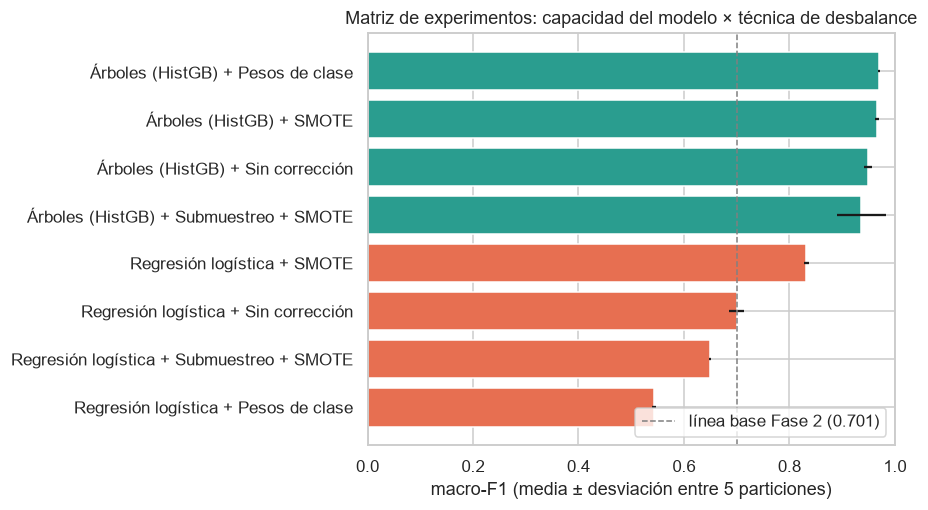

In [3]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
datos = macro.sort_values("macro_f1_media")
etiquetas = datos["modelo"] + " + " + datos["tecnica"]
colores = ["#e76f51" if m == "Regresión logística" else "#2a9d8f" for m in datos["modelo"]]
ax.barh(etiquetas, datos["macro_f1_media"], xerr=datos["macro_f1_desv"], color=colores)
ax.axvline(0.701, color="gray", ls="--", lw=1, label="línea base Fase 2 (0.701)")
ax.set_xlabel("macro-F1 (media ± desviación entre 5 particiones)")
ax.set_title("Matriz de experimentos: capacidad del modelo × técnica de desbalance")
ax.set_xlim(0, 1.0)
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "07_macro_f1_experimentos.png", bbox_inches="tight")
plt.show()

**Dos lecturas inmediatas:**

1. **El eje del modelo pesa más que el eje del desbalance.** El peor de los árboles
   (0,937) supera a la mejor logística (0,832). Es decir, la brecha de las clases
   minoritarias venía sobre todo de la **capacidad del modelo** (las fronteras no son
   lineales), además del desbalance.
2. **Reponderar un modelo sin capacidad empeora las cosas:** los pesos de clase hunden
   a la logística (de 0,700 a 0,543). Los pesos la obligan a atender clases que no puede
   separar con una frontera lineal, y el resultado es una gran cantidad de falsas
   alarmas (lo cuantificamos más abajo).

## 2. Detalle por clase: recall, precisión y AP de las minoritarias

Aquí hay tres vistas que se complementan: el **recall** (¿qué fracción de los ataques
reales detecta?), la **precisión** (¿qué fracción de sus alarmas es correcta?) y el
**AP** (la calidad del ordenamiento completo, sin depender del umbral).

In [4]:
def pivote(df, clases, decimales=3):
    """Tabla combinación × clase con 'media ± desv' como texto."""
    sel = df[df["clase"].isin(clases)].copy()
    sel["texto"] = sel.apply(lambda r: f"{r['media']:.{decimales}f} ± {r['desv']:.{decimales}f}", axis=1)
    piv = sel.pivot_table(
        index=["modelo", "tecnica"], columns="clase", values="texto", aggfunc="first"
    )[clases]
    orden = pd.MultiIndex.from_product([ORDEN_MODELOS, ORDEN_TECNICAS])
    return piv.reindex(orden)

columnas = CLASES_MINORITARIAS + ["BENIGN"]
print("RECALL por clase (media ± desviación entre las 5 particiones)")
pivote(recall, columnas)

RECALL por clase (media ± desviación entre las 5 particiones)


clase                                              Bot     Web Attack  \
Regresión logística Sin corrección       0.015 ± 0.010  0.003 ± 0.004   
                    Pesos de clase       0.993 ± 0.003  0.955 ± 0.007   
                    SMOTE                0.350 ± 0.017  0.887 ± 0.016   
                    Submuestreo + SMOTE  0.383 ± 0.016  0.909 ± 0.019   
Árboles (HistGB)    Sin corrección       0.793 ± 0.111  0.935 ± 0.022   
                    Pesos de clase       0.980 ± 0.011  0.987 ± 0.011   
                    SMOTE                0.981 ± 0.006  0.976 ± 0.017   
                    Submuestreo + SMOTE  0.987 ± 0.006  0.988 ± 0.005   

clase                                      SSH-Patator DoS Slowhttptest  \
Regresión logística Sin corrección       0.208 ± 0.129    0.796 ± 0.007   
                    Pesos de clase       0.982 ± 0.005    0.985 ± 0.005   
                    SMOTE                0.916 ± 0.012    0.960 ± 0.007   
                    Submuestreo + SMOTE  0.977 ± 0.007    0.973 ± 0.006   
Árboles (HistGB)    Sin corrección       0.995 ± 0.004    0.947 ± 0.018   
                    Pesos de clase       1.000 ± 0.001    0.994 ± 0.002   
                    SMOTE                0.998 ± 0.003    0.989 ± 0.005   
                    Submuestreo + SMOTE  0.999 ± 0.001    0.986 ± 0.015   

clase                                    DoS slowloris         BENIGN  
Regresión logística Sin corrección       0.885 ± 0.012  0.982 ± 0.000  
                    Pesos de clase       0.978 ± 0.006  0.842 ± 0.002  
                    SMOTE                0.908 ± 0.009  0.980 ± 0.001  
                    Submuestreo + SMOTE  0.914 ± 0.008  0.923 ± 0.001  
Árboles (HistGB)    Sin corrección       0.963 ± 0.027  0.998 ± 0.000  
                    Pesos de clase       0.996 ± 0.003  0.998 ± 0.000  
                    SMOTE                0.991 ± 0.003  0.999 ± 0.000  
                    Submuestreo + SMOTE  0.988 ± 0.015  0.996 ± 0.004

In [5]:
print("PRECISIÓN por clase — el costo en falsas alarmas")
pivote(precision, columnas)

PRECISIÓN por clase — el costo en falsas alarmas


clase                                              Bot     Web Attack  \
Regresión logística Sin corrección       0.730 ± 0.284  0.225 ± 0.266   
                    Pesos de clase       0.020 ± 0.001  0.033 ± 0.001   
                    SMOTE                0.669 ± 0.034  0.379 ± 0.062   
                    Submuestreo + SMOTE  0.063 ± 0.002  0.047 ± 0.001   
Árboles (HistGB)    Sin corrección       0.643 ± 0.111  0.887 ± 0.030   
                    Pesos de clase       0.614 ± 0.039  0.952 ± 0.017   
                    SMOTE                0.647 ± 0.016  0.885 ± 0.053   
                    Submuestreo + SMOTE  0.512 ± 0.065  0.787 ± 0.310   

clase                                      SSH-Patator DoS Slowhttptest  \
Regresión logística Sin corrección       0.787 ± 0.148    0.819 ± 0.012   
                    Pesos de clase       0.097 ± 0.002    0.334 ± 0.016   
                    SMOTE                0.867 ± 0.023    0.784 ± 0.008   
                    Submuestreo + SMOTE  0.312 ± 0.012    0.618 ± 0.023   
Árboles (HistGB)    Sin corrección       0.984 ± 0.008    0.907 ± 0.057   
                    Pesos de clase       0.997 ± 0.002    0.977 ± 0.005   
                    SMOTE                0.997 ± 0.004    0.956 ± 0.012   
                    Submuestreo + SMOTE  0.973 ± 0.033    0.925 ± 0.086   

clase                                    DoS slowloris         BENIGN  
Regresión logística Sin corrección       0.958 ± 0.006  0.989 ± 0.000  
                    Pesos de clase       0.178 ± 0.003  1.000 ± 0.000  
                    SMOTE                0.904 ± 0.006  0.992 ± 0.000  
                    Submuestreo + SMOTE  0.441 ± 0.003  0.999 ± 0.000  
Árboles (HistGB)    Sin corrección       0.945 ± 0.015  0.999 ± 0.000  
                    Pesos de clase       0.976 ± 0.010  1.000 ± 0.000  
                    SMOTE                0.966 ± 0.015  1.000 ± 0.000  
                    Submuestreo + SMOTE  0.955 ± 0.032  1.000 ± 0.000

In [6]:
print("AP por clase (área bajo la curva precision-recall, uno-contra-resto)")
pivote(ap, CLASES_MINORITARIAS)

AP por clase (área bajo la curva precision-recall, uno-contra-resto)


clase                                              Bot     Web Attack  \
Regresión logística Sin corrección       0.221 ± 0.020  0.298 ± 0.066   
                    Pesos de clase       0.129 ± 0.018  0.117 ± 0.022   
                    SMOTE                0.247 ± 0.017  0.583 ± 0.062   
                    Submuestreo + SMOTE  0.247 ± 0.025  0.152 ± 0.017   
Árboles (HistGB)    Sin corrección       0.540 ± 0.039  0.854 ± 0.044   
                    Pesos de clase       0.911 ± 0.016  0.990 ± 0.006   
                    SMOTE                0.922 ± 0.011  0.859 ± 0.041   
                    Submuestreo + SMOTE  0.815 ± 0.245  0.731 ± 0.343   

clase                                      SSH-Patator DoS Slowhttptest  \
Regresión logística Sin corrección       0.802 ± 0.016    0.850 ± 0.018   
                    Pesos de clase       0.623 ± 0.030    0.646 ± 0.026   
                    SMOTE                0.839 ± 0.021    0.801 ± 0.018   
                    Submuestreo + SMOTE  0.673 ± 0.040    0.730 ± 0.017   
Árboles (HistGB)    Sin corrección       0.985 ± 0.008    0.870 ± 0.067   
                    Pesos de clase       1.000 ± 0.000    0.993 ± 0.002   
                    SMOTE                0.999 ± 0.002    0.915 ± 0.037   
                    Submuestreo + SMOTE  0.968 ± 0.058    0.863 ± 0.176   

clase                                    DoS slowloris  
Regresión logística Sin corrección       0.912 ± 0.008  
                    Pesos de clase       0.875 ± 0.014  
                    SMOTE                0.914 ± 0.005  
                    Submuestreo + SMOTE  0.896 ± 0.013  
Árboles (HistGB)    Sin corrección       0.924 ± 0.028  
                    Pesos de clase       0.995 ± 0.008  
                    SMOTE                0.952 ± 0.016  
                    Submuestreo + SMOTE  0.894 ± 0.090

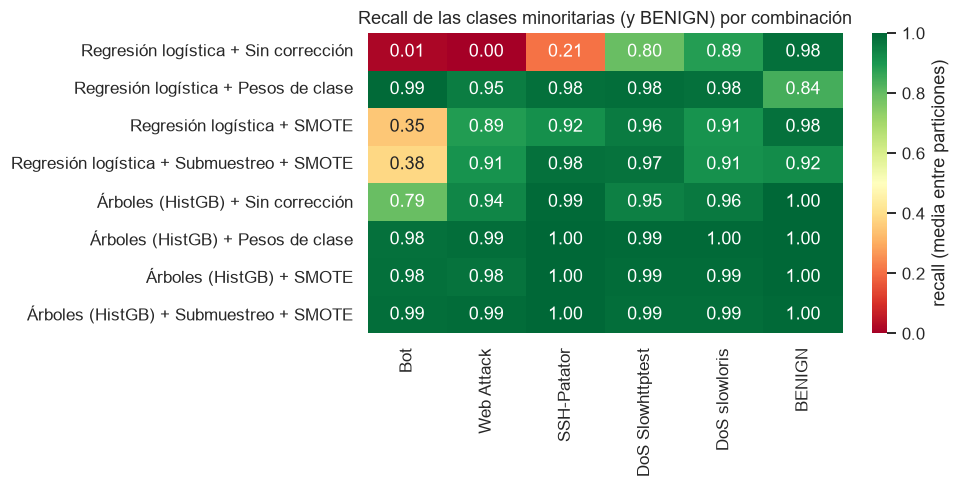

In [7]:
# Mapa de calor del recall medio (media de las 5 particiones) por combinación
piv_num = (
    recall[recall["clase"].isin(columnas)]
    .pivot_table(index=["modelo", "tecnica"], columns="clase", values="media")
    .reindex(pd.MultiIndex.from_product([ORDEN_MODELOS, ORDEN_TECNICAS]))[columnas]
)
piv_num.index = [f"{m} + {t}" for m, t in piv_num.index]

fig, ax = plt.subplots(figsize=(9, 4.6))
sns.heatmap(piv_num, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1,
            cbar_kws={"label": "recall (media entre particiones)"}, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Recall de las clases minoritarias (y BENIGN) por combinación")
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "08_recall_minoritarias.png", bbox_inches="tight")
plt.show()

## 3. Análisis: qué mejora, qué estaba estancado y qué lo resolvió

**(a) Clases que solo necesitaban reponderar o mover el umbral.** SSH-Patator es el
ejemplo más claro: con la logística sin corrección tenía un recall de 0,21 pero un
**AP de 0,80**, es decir, el modelo ya la *ordenaba* bien y lo que la frenaba era el
umbral. Cualquier corrección la mejora (recall de 0,92-0,98 con SMOTE o con pesos).
DoS slowloris y DoS Slowhttptest (AP de 0,91 y 0,85 de base) se comportan igual.

**(b) Clases que el modelo lineal no pudo resolver, hiciera lo que hiciera.** Bot y Web
Attack tenían un AP de base de 0,22 y 0,30, porque la logística **no puede separarlas**
con fronteras lineales, sin importar dónde se ponga el umbral. La prueba es que con
pesos de clase su recall sube (0,99 y 0,96) pero la precisión cae a **0,02 y 0,03**: de
cada 100 alarmas de Bot, 98 son falsas. SMOTE ayuda un poco (el AP de Web Attack pasa
de 0,30 a 0,58), pero no alcanza para resolverlas.

**(c) Los árboles sí las recuperan.** Solo con cambiar de modelo (sin ninguna
corrección), el AP de Bot pasa de 0,22 a 0,54 y el de Web Attack de 0,30 a 0,85. Si
además se agregan pesos de clase, se llega a **Bot con AP 0,91 (recall 0,98, precisión
0,61)** y **Web Attack con AP 0,99 (recall 0,99, precisión 0,95)**. La conclusión
metodológica es importante para la tesis: *la causa principal del problema era la falta
de capacidad del modelo, más que el desbalance*. Las técnicas de desbalance ayudan (de
0,948 a 0,970), pero solo cuando el modelo ya puede representar la frontera.

**(d) El costo en falsas alarmas.** Reponderar la logística vuelve el sistema inútil en
la práctica: BENIGN cae a un recall de 0,842, es decir, **~264.000 flujos normales
marcados como ataque** (unas 16 falsas alarmas por cada 100 flujos benignos), algo que
ningún analista podría revisar. Los árboles con pesos casi no pagan ese costo: BENIGN
mantiene un recall de 0,998 y una precisión de 1,000.

**Lo que queda por mejorar:** la debilidad que le queda al mejor modelo es la
**precisión de Bot (0,61)**, es decir, cerca de 4 de cada 10 alarmas de Bot son falsas
(967 flujos benignos confundidos con Bot, ver la matriz). Su AP de 0,91 indica que hay
margen si se ajusta el umbral (cambiando algo de recall por precisión), pero ese ajuste
corresponde a la Fase 4.

## 4. La mejor combinación: árboles + pesos de clase

Mejor combinación: Árboles (HistGB) + Pesos de clase (macro-F1 = 0.970 ± 0.002)


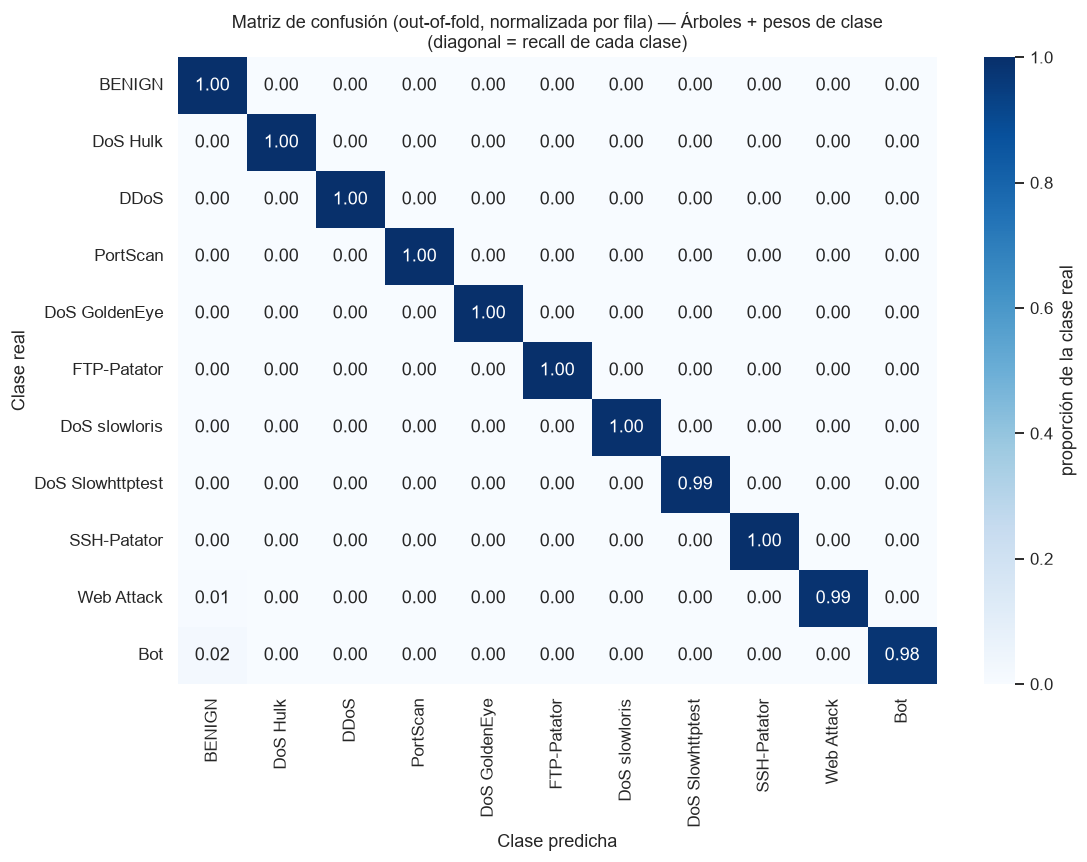

In [8]:
mejor = macro.iloc[0]
print(f"Mejor combinación: {mejor['modelo']} + {mejor['tecnica']} "
      f"(macro-F1 = {mejor['macro_f1_media']:.3f} ± {mejor['macro_f1_desv']:.3f})")

conf = pd.read_csv(RUTA_EXPORT / "fase3_confusion__arboles__pesos.csv", index_col=0)
orden_tam = conf.sum(axis=1).sort_values(ascending=False).index
conf = conf.loc[orden_tam, orden_tam]
conf_norm = conf.div(conf.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(10.5, 8))
sns.heatmap(conf_norm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            cbar_kws={"label": "proporción de la clase real"}, ax=ax)
ax.set_ylabel("Clase real")
ax.set_xlabel("Clase predicha")
ax.set_title(
    "Matriz de confusión (out-of-fold, normalizada por fila) — Árboles + pesos de clase\n"
    "(diagonal = recall de cada clase)"
)
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "09_confusion_mejor_combinacion.png", bbox_inches="tight")
plt.show()

In [9]:
# Los errores en números absolutos, para ver cuántas falsas alarmas genera
benign_mal = int(conf.loc["BENIGN"].drop("BENIGN").sum())
total_benign = int(conf.loc["BENIGN"].sum())
print(f"Flujos BENIGN marcados como algún ataque: {benign_mal:,} de {total_benign:,} "
      f"({100 * benign_mal / total_benign:.2f}%)")
print("Principales confusiones desde BENIGN:")
print(conf.loc["BENIGN"].drop("BENIGN").sort_values(ascending=False).head(3).to_string())
conf

Flujos BENIGN marcados como algún ataque: 3,157 de 1,657,869 (0.19%)
Principales confusiones desde BENIGN:
DoS Hulk    1047
Bot          967
PortScan     794


,BENIGN,DoS Hulk,DDoS,PortScan,DoS GoldenEye,FTP-Patator,DoS slowloris,DoS Slowhttptest,SSH-Patator,Web Attack,Bot
BENIGN,1654712,1047,50,794,55,3,90,80,6,65,967
DoS Hulk,21,138143,0,17,93,0,1,0,0,2,0
DDoS,22,0,102389,0,0,0,0,0,0,0,0
PortScan,3,20,0,72522,0,0,0,1,1,8,0
DoS GoldenEye,1,7,0,0,8214,0,0,7,0,0,0
FTP-Patator,1,0,0,0,0,4743,0,0,0,1,0
DoS slowloris,8,1,0,0,0,0,4290,4,0,5,0
DoS Slowhttptest,3,1,0,0,2,0,15,4156,0,5,0
SSH-Patator,1,0,0,0,0,0,0,0,2574,0,0
Web Attack,11,3,0,0,4,0,1,4,0,1692,0


## 5. Curvas Precision-Recall de las clases que la logística no podía separar

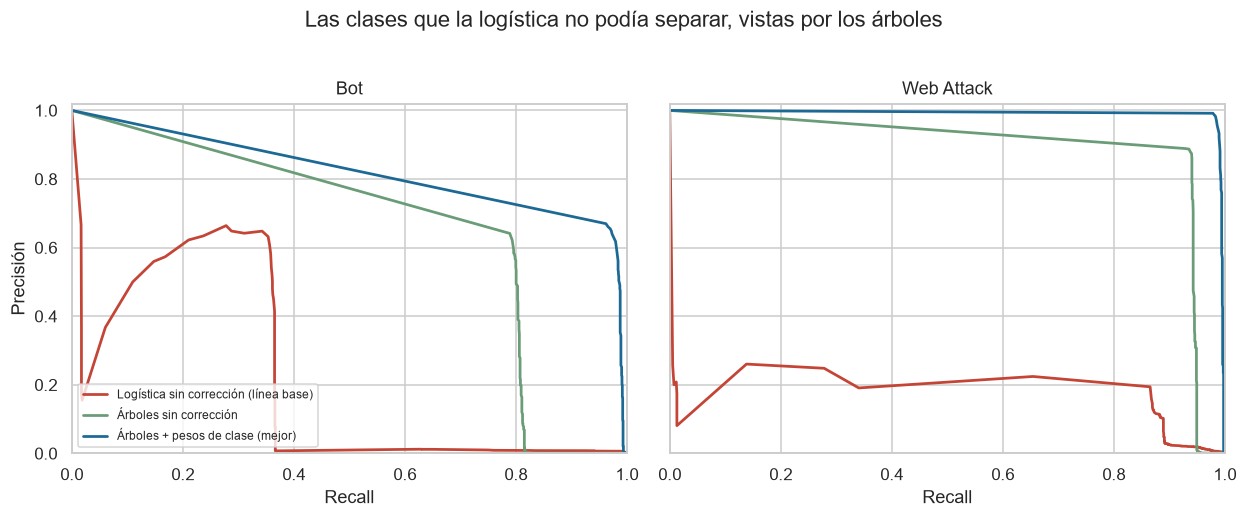

In [10]:
combos_pr = [
    ("reglog", "sin_correccion", "Logística sin corrección (línea base)", "#c44536"),
    ("arboles", "sin_correccion", "Árboles sin corrección", "#6a9c78"),
    ("arboles", "pesos", "Árboles + pesos de clase (mejor)", "#1d6996"),
]
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), sharey=True)
for ax, clase in zip(axes, ["Bot", "Web Attack"]):
    for modelo, tecnica, nombre, color in combos_pr:
        pr = pd.read_csv(RUTA_EXPORT / f"fase3_pr__{modelo}__{tecnica}.csv")
        pr = pr[pr["clase"] == clase]
        ax.plot(pr["recall"], pr["precision"], lw=1.8, label=nombre, color=color)
    ax.set_title(f"{clase}")
    ax.set_xlabel("Recall")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
axes[0].set_ylabel("Precisión")
axes[0].legend(fontsize=8, loc="lower left")
fig.suptitle("Las clases que la logística no podía separar, vistas por los árboles", y=1.02)
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "10_pr_clases_atascadas.png", bbox_inches="tight")
plt.show()

## 6. Conclusiones de la fase

| Hallazgo | Evidencia |
|---|---|
| La capacidad del modelo importó más que la técnica de desbalance | Peor árbol (0,937) > mejor logística (0,832) |
| Reponderar un modelo sin capacidad empeora el resultado | Logística + pesos: de 0,700 a 0,543; precisión de Bot 0,02 |
| Las clases con AP alto de base solo necesitaban corrección | SSH-Patator: recall de 0,21 a 0,98-1,00 |
| Bot y Web Attack mejoraron al cambiar de modelo, más que por el remuestreo | AP de 0,22/0,30 a 0,54/0,85 solo con árboles, sin corrección |
| **Mejor combinación: árboles + pesos de clase** | macro-F1 **0,970 ± 0,002**; 0,19% de falsas alarmas sobre BENIGN |
| Lo que queda por mejorar | Precisión de Bot 0,61 (967 falsas alarmas); el umbral se puede ajustar en la Fase 4 |
| Submuestreo + SMOTE es inestable con árboles | Desviación de 0,046 (una partición cayó a 0,846), por eso se descarta |

**El conjunto de prueba sigue sin tocarse.** El candidato para la evaluación final única
sobre el test es **árboles + pesos de clase**, y queda pendiente de revisión confirmarlo
antes de pasar a las preguntas 1 (interpretabilidad) y 3 (detección no supervisada).